In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
print(f"Dane wczytane: {df.shape[0]} wierszy, {df.shape[1]} kolumn")

Dane wczytane: 244 wierszy, 7 kolumn


In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [8]:
df.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
df.dtypes

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

In [10]:
df.columns.tolist()

['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

## Wnioski z eksploracji
- Dataset zawiera ... wierszy i ... kolumn
- Kolumny numeryczne: ...
- Kolumny tekstowe: ...
- Brakujące wartości: ... (sprawdź wynik info())
- Średni rachunek wynosi ... $

## Pytania biznesowe

In [13]:
df['total_bill'].max() # największa wartość

np.float64(50.81)

In [14]:
df['total_bill'].min() # najmniejsza wartość

np.float64(3.07)

In [15]:
df['total_bill'].mean() # średnia

np.float64(19.78594262295082)

In [16]:
# Pytanie 2: Rachunki wg dnia
df['day'].value_counts() # zlicza wystąpienia każdej wartości

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [17]:
# Pytanie 3: Napiwki — palący vs niepalący
df.groupby('smoker')['tip'].mean()

smoker
No     2.991854
Yes    3.008710
Name: tip, dtype: float64

In [20]:
# Pytanie 4: Procent napiwku
df['nowa_kolumna'] = df['tip'] / df['total_bill'] * 100
df['nowa_kolumna'].mean()

np.float64(16.08025817225047)

In [21]:
# Pytanie 5: Dzień + pora → rachunki
df.groupby(['day', 'time'])['total_bill'].mean()

day   time  
Fri   Dinner    19.663333
      Lunch     12.845714
Sat   Dinner    20.441379
Sun   Dinner    21.410000
Thur  Dinner    18.780000
      Lunch     17.664754
Name: total_bill, dtype: float64

## Wizualizacja


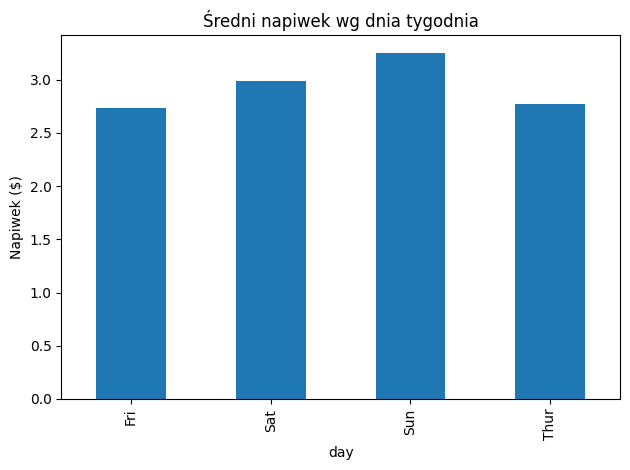

In [22]:
df.groupby('day')['tip'].mean().plot(kind='bar', title='Średni napiwek wg dnia tygodnia')
plt.ylabel('Napiwek ($)')
plt.tight_layout()
plt.show()